### Homework 5: Question search engine

Remeber week01 where you used GloVe embeddings to find related questions? That was.. cute, but far from state of the art. It's time to really solve this task using context-aware embeddings.

__Warning:__ this task assumes you have seen `seminar.ipynb`!

In [ ]:
%pip install --upgrade transformers datasets accelerate deepspeed
import torch
import torch.nn as nn
import torch.nn.functional as F
import transformers
import datasets
import numpy as np
from tqdm import tqdm

### Load data and model

In [2]:
qqp = datasets.load_dataset('SetFit/qqp')
print('\n')
print("Sample[0]:", qqp['train'][0])
print("Sample[3]:", qqp['train'][3])

Extracting data files:   0%|          | 0/3 [00:00<?, ?it/s]

Dataset json downloaded and prepared to /root/.cache/huggingface/datasets/json/SetFit--qqp-94258451190e12bb/0.0.0/ac0ca5f5289a6cf108e706efcf040422dbbfa8e658dee6a819f20d76bb84d26b. Subsequent calls will reuse this data.


  0%|          | 0/3 [00:00<?, ?it/s]



Sample[0]: {'text1': 'How is the life of a math student? Could you describe your own experiences?', 'text2': 'Which level of prepration is enough for the exam jlpt5?', 'label': 0, 'idx': 0, 'label_text': 'not duplicate'}
Sample[3]: {'text1': 'What can one do after MBBS?', 'text2': 'What do i do after my MBBS ?', 'label': 1, 'idx': 3, 'label_text': 'duplicate'}


In [23]:
n=100000
arr_len_text_1=np.zeros(n)
arr_len_text_2=np.zeros(n)

for i in tqdm(range(n)):
    arr_len_text_1[i]=len(qqp['train'][i]['text1'].split())
    arr_len_text_2[i]=len(qqp['train'][i]['text2'].split())

100%|██████████| 100000/100000 [00:19<00:00, 5097.98it/s]


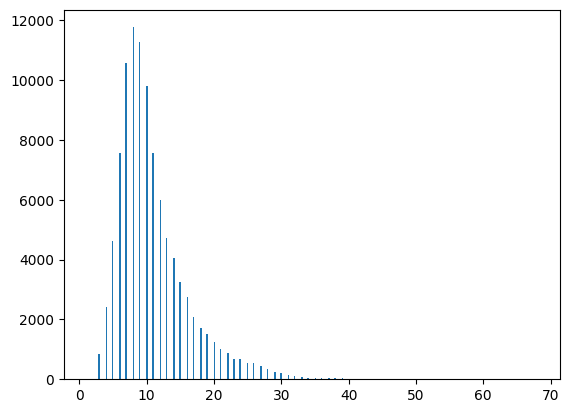

In [24]:
# текст 1
p1=plt.hist(arr_len_text_1,bins=300)

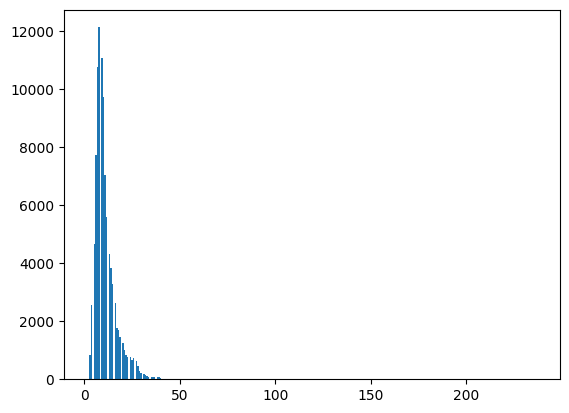

In [25]:
# текст 2
p2=plt.hist(arr_len_text_2,bins=300)

In [26]:
model_name = "gchhablani/bert-base-cased-finetuned-qqp"
tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)
model = transformers.AutoModelForSequenceClassification.from_pretrained(model_name)

### Tokenize the data

In [27]:
MAX_LENGTH = 128
def preprocess_function(examples):
    result = tokenizer(
        examples['text1'], examples['text2'],
        padding='max_length', max_length=MAX_LENGTH, truncation=True
    )
    result['label'] = examples['label']
    return result

qqp_preprocessed = qqp.map(preprocess_function, batched=True)

  0%|          | 0/364 [00:00<?, ?ba/s]

  0%|          | 0/391 [00:00<?, ?ba/s]

  0%|          | 0/41 [00:00<?, ?ba/s]

In [28]:
print(repr(qqp_preprocessed['train'][0]['input_ids'])[:100], "...")

[101, 1731, 1110, 1103, 1297, 1104, 170, 12523, 2377, 136, 7426, 1128, 5594, 1240, 1319, 5758, 136,  ...


### Task 1: evaluation (1 point)

We randomly chose a model trained on QQP - but is it any good?

One way to measure this is with validation accuracy - which is what you will implement next.

Here's the interface to help you do that:

In [29]:
import numpy as np
from tqdm import tqdm

In [30]:
val_set = qqp_preprocessed['validation']
val_loader = torch.utils.data.DataLoader(
    val_set, batch_size=1, shuffle=False, collate_fn=transformers.default_data_collator
)

In [31]:
for batch in val_loader:
     break  # here be your training code
print("Sample batch:", batch)

with torch.no_grad():
    predicted = model(
      input_ids=batch['input_ids'],
      attention_mask=batch['attention_mask'],
      token_type_ids=batch['token_type_ids']
    )

print('\nPrediction (probs):', torch.softmax(predicted.logits, dim=1).data.numpy())

Sample batch: {'labels': tensor([0]), 'idx': tensor([0]), 'input_ids': tensor([[  101,  2009,  1132,  2170,   118,  4038,  1177,  2712,   136,   102,
          2009,  1132,  1117, 10224,  4724,  1177,  2712,   136,   102,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,   

__Your task__ is to measure the validation accuracy of your model.
Doing so naively may take several hours. Please make sure you use the following optimizations:

- run the model on GPU with no_grad
- using batch size larger than 1
- use optimize data loader with num_workers > 1
- (optional) use [mixed precision](https://pytorch.org/docs/stable/notes/amp_examples.html)


In [32]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [33]:
model=model.to(device)

In [34]:
val_loader = torch.utils.data.DataLoader(
    val_set, batch_size=16, shuffle=False, collate_fn=transformers.default_data_collator ,num_workers=2
)

In [35]:
accuracy=0

count=0

for batch in tqdm(val_loader):
    
    with torch.no_grad():
        predicted = model(
          input_ids=batch['input_ids'].to(device),
          attention_mask=batch['attention_mask'].to(device),
          token_type_ids=batch['token_type_ids'].to(device)
    )
        
    answer = np.argmax(torch.softmax(predicted.logits, dim=1).data.cpu().detach().numpy(),axis=1)
    cur_batch_size=batch['labels'].numpy().shape[0]
    
    acc = np.sum(answer==batch['labels'].numpy())/cur_batch_size
#     print(acc)
    
    accuracy = (accuracy*count+acc*cur_batch_size)/(count+cur_batch_size)
#     print(accuracy)
    count += cur_batch_size
#     if count>100:
#         break
        
print(accuracy)

  0%|          | 0/2527 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  0%|          | 1/2527 [00:00<07:46,  5.42it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


100%|██████████| 2527/2527 [02:33<00:00, 16.41it/s]

0.9083848627256991


In [36]:
assert 0.9 < accuracy < 0.91

### Task 2: train the model (4 points)

For this task, you have two options:

__Option A:__ fine-tune your own model. You are free to choose any model __except for the original BERT.__ We recommend [DeBERTa-v3](https://huggingface.co/microsoft/deberta-v3-base). Better yet, choose the best model based on public benchmarks (e.g. [GLUE](https://gluebenchmark.com/)).

You can write the training code manually or use transformers.Trainer (see [this example](https://github.com/huggingface/transformers/blob/main/examples/pytorch/text-classification)). Please make sure that your model's accuracy is at least __comparable__ with the above example for BERT.


__Option B:__ compare at least 3 pre-finetuned models (in addition to the above BERT model). For each model, report (1) its accuracy, (2) its speed, measured in samples per second in your hardware setup and (3) its size in megabytes. Please take care to compare models in equal setting, e.g. same CPU / GPU. Compile your results into a table and write a short (~half-page on top of a table) report, summarizing your findings.

DeBERTa's a GLUE leader. Let's start with the large version -  https://huggingface.co/microsoft/deberta-large

In [3]:
model_name = "microsoft/deberta-large"
tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)
model_my = transformers.AutoModelForSequenceClassification.from_pretrained(model_name)

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Some weights of DebertaForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-large and are newly initialized: ['classifier.weight', 'classifier.bias', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [5]:
model_my=model_my.to(device)

In [ ]:
MAX_LENGTH = 60 #По гистограмме видно, что тексты не длиннее 30 слов, возьмем 60
def preprocess_function(examples):
    result = tokenizer(
        examples['text1'], examples['text2'],
        padding='max_length', max_length=MAX_LENGTH, truncation=True
    )
    result['label'] = examples['label']
    return result

qqp_preprocessed = qqp.map(preprocess_function, batched=True)

  0%|          | 0/364 [00:00<?, ?ba/s]

  0%|          | 0/391 [00:00<?, ?ba/s]

  0%|          | 0/41 [00:00<?, ?ba/s]

In [17]:
val_set = qqp_preprocessed['validation']
val_loader = torch.utils.data.DataLoader(
    val_set, batch_size=8, shuffle=False, collate_fn=transformers.default_data_collator
)

In [13]:
loss = nn.CrossEntropyLoss()

def compute_loss(model, batch):
    predicted = model(
      input_ids=batch['input_ids'].to(device),
      attention_mask=batch['attention_mask'].to(device),
      token_type_ids=batch['token_type_ids'].to(device)
    )
    y_pred = predicted.logits
#     torch.softmax(, dim=1)
    y_real=batch['labels'].to(device)
    return loss(y_pred,y_real)

def accuracy(model):
    
    val_loader = torch.utils.data.DataLoader(
    val_set, batch_size=8, shuffle=True, collate_fn=transformers.default_data_collator
    )
    
    accuracy = 0
    count=0
#     c=0
    for batch in tqdm(val_loader):
        
        with torch.no_grad():
            predicted = model(
              input_ids=batch['input_ids'].to(device),
              attention_mask=batch['attention_mask'].to(device),
              token_type_ids=batch['token_type_ids'].to(device)
        )

        answer = np.argmax(torch.softmax(predicted.logits, dim=1).data.cpu().detach().numpy(),axis=1)
        cur_batch_size=batch['labels'].numpy().shape[0]

        acc = np.sum(answer==batch['labels'].numpy())/cur_batch_size

    
        accuracy = (accuracy*count+acc*cur_batch_size)/(count+cur_batch_size)
        count+=cur_batch_size
#         c+=1
#         if c>1000:
#             break
        
    return accuracy

In [9]:
from IPython.display import clear_output
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
# , trange
metrics = {'train_loss': [], 'val_accuracy': [] }
# {'train_loss': []}
# {'train_loss': [], 'val_accuracy': [] }

# .to(device)
opt = torch.optim.Adam(model_my.parameters(), lr = 2e-5,eps = 1e-8)
batch_size = 16

In [10]:
train_set = qqp_preprocessed['train']

In [ ]:
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=batch_size, shuffle=True, collate_fn=transformers.default_data_collator
)

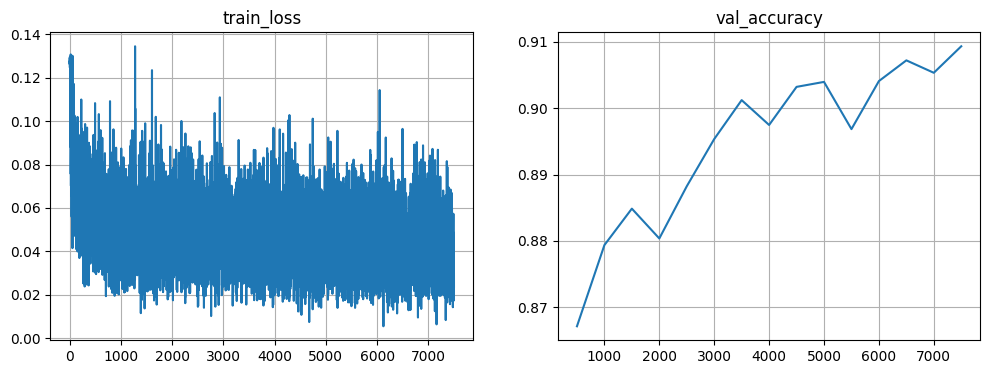

Mean loss=0.034


100%|██████████| 22741/22741 [2:44:33<00:00,  2.30it/s]  


In [12]:
accum_iter = 4
batch_id=0
sum_loss = 0

for batch in tqdm(train_loader):

    step = len(metrics['train_loss']) + 1
    
    loss_t = compute_loss(model_my, batch)
    
    loss_t = loss_t / accum_iter 

    # backward pass
    loss_t.backward()
    
    batch_id+=1
    sum_loss += loss_t.item()
    
    # gradient accumulation
    if ((batch_id + 1) % accum_iter == 0) or (batch_id + 1 == len(train_loader)):
            opt.step()
            opt.zero_grad()
            batch_id=0
            
            metrics['train_loss'].append((step, sum_loss/accum_iter))
            sum_loss = 0

            if step % 500 == 0:
                metrics['val_accuracy'].append((step, accuracy(model_my)))

                clear_output(True)
                plt.figure(figsize=(12,4))
                for i, (name, history) in enumerate(sorted(metrics.items())):
                    plt.subplot(1, len(metrics), i + 1)
                    plt.title(name)
                    plt.plot(*zip(*history))
                    plt.grid()
                plt.show()
                print("Mean loss=%.3f" % np.mean(metrics['train_loss'][-10:], axis=0)[1], flush=True)

In [14]:
torch.save(model_my, 'model_my')

## Let's fine-tune the model some more

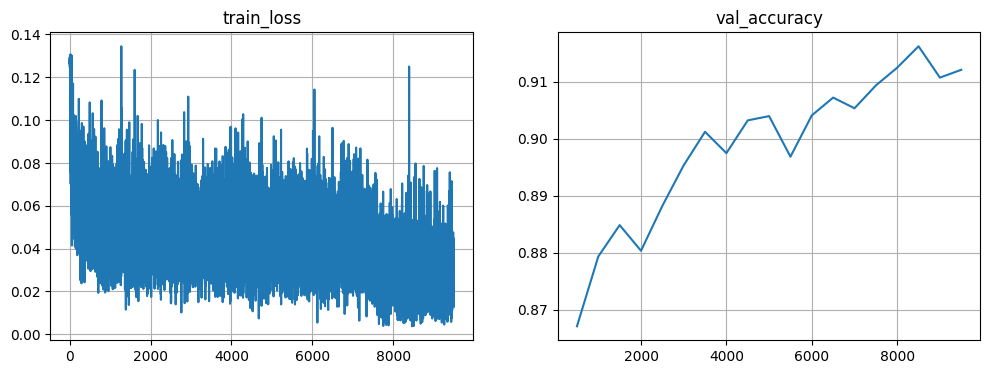

Mean loss=0.028


 27%|██▋       | 6050/22741 [43:55<2:01:11,  2.30it/s]  


In [15]:
break_= 0 
# 6050
for batch in tqdm(train_loader):

    step = len(metrics['train_loss']) + 1
    
    loss_t = compute_loss(model_my, batch)
    
    loss_t = loss_t / accum_iter 

    # backward pass
    loss_t.backward()
    
    batch_id+=1
    sum_loss += loss_t.item()
    break_ +=1
    if break_>6050:
        break
    # gradient accumulation
    if ((batch_id + 1) % accum_iter == 0) or (batch_id + 1 == len(train_loader)):
            opt.step()
            opt.zero_grad()
            batch_id=0
            
            metrics['train_loss'].append((step, sum_loss/accum_iter))
            sum_loss = 0

            if step % 500 == 0:
                metrics['val_accuracy'].append((step, accuracy(model_my)))

                clear_output(True)
                plt.figure(figsize=(12,4))
                for i, (name, history) in enumerate(sorted(metrics.items())):
                    plt.subplot(1, len(metrics), i + 1)
                    plt.title(name)
                    plt.plot(*zip(*history))
                    plt.grid()
                plt.show()
                print("Mean loss=%.3f" % np.mean(metrics['train_loss'][-10:], axis=0)[1], flush=True)

In [22]:
torch.save(model_my, 'model_my')

In [ ]:
acc=accuracy(model_my)
acc

100%|██████████| 5054/5054 [06:05<00:00, 13.83it/s]


0.9075191689339599

### Task 3: try the full pipeline (1 point)

Finally, it is time to use your model to find duplicate questions.
Please implement a function that takes a question and finds top-5 potential duplicates in the training set. For now, it is fine if your function is slow, as long as it yields correct results.

Showcase how your function works with at least 5 examples.

In [6]:
qqp = datasets.load_dataset('SetFit/qqp')

Extracting data files:   0%|          | 0/3 [00:00<?, ?it/s]

Dataset json downloaded and prepared to /root/.cache/huggingface/datasets/json/SetFit--qqp-94258451190e12bb/0.0.0/ac0ca5f5289a6cf108e706efcf040422dbbfa8e658dee6a819f20d76bb84d26b. Subsequent calls will reuse this data.


  0%|          | 0/3 [00:00<?, ?it/s]

In [20]:
model_name = "microsoft/deberta-large"
tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)

In [37]:
model = torch.load('/kaggle/input/model-my-2/model_my_2')

In [38]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [33]:
MAX_LENGTH = 64

In [55]:
def search(query,batch_size=8):
    
    n = len(qqp['train']['text1'])
    count = 0
    potential_answers=np.zeros(n*2)
    
    def preprocess_function_(examples):
        result = tokenizer(
            [query]*len(examples['text1']), examples['text1'],
            padding='max_length', max_length=MAX_LENGTH, truncation=True
        )
        return result
    
    qqp_preprocessed_1 = qqp.map(preprocess_function_, batched=True)
    
    search_loader_1 = torch.utils.data.DataLoader(
        qqp_preprocessed_1['train'], batch_size=batch_size, shuffle=False, collate_fn=transformers.default_data_collator #,num_workers=2
    )
    
    for search_batch in tqdm(search_loader_1):
        
        with torch.no_grad():
            predicted = model(
              input_ids=search_batch['input_ids'].to(device),
              attention_mask=search_batch['attention_mask'].to(device),
              token_type_ids=search_batch['token_type_ids'].to(device)
        )
            
        answer = torch.softmax(predicted.logits, dim=1).data.cpu().detach().numpy()[:,1]
        
        potential_answers[count:count+len(answer)] = answer
        count+=len(answer)
    
    def preprocess_function_(examples):
        result = tokenizer(
            [query]*len(examples['text2']), examples['text2'],
            padding='max_length', max_length=MAX_LENGTH, truncation=True
        )
        return result
    
    qqp_preprocessed_2 = qqp.map(preprocess_function_, batched=True)
    
    search_loader_2 = torch.utils.data.DataLoader(
        qqp_preprocessed_2['train'], batch_size=batch_size, shuffle=False, collate_fn=transformers.default_data_collator #,num_workers=2
    )
    
    for search_batch in tqdm(search_loader_2):
        
        with torch.no_grad():
            predicted = model(
              input_ids=search_batch['input_ids'].to(device),
              attention_mask=search_batch['attention_mask'].to(device),
              token_type_ids=search_batch['token_type_ids'].to(device)
        )
            
        answer = torch.softmax(predicted.logits, dim=1).data.cpu().detach().numpy()[:,1]
        
        potential_answers[count:count+len(answer)] = answer
        count+=len(answer)
    
    potential_answers_sorted = np.argsort(potential_answers)[::-1]
    
    answer = []
    
    for i in range(5):
        if potential_answers_sorted[i]<=n-1:
            answer.append(qqp['train']['text1'][potential_answers_sorted[i]])
        else:
            answer.append(qqp['train']['text2'][potential_answers_sorted[i]-n])
            
    return answer
#     return potential_answers[0:batch_size*600], qqp['train']['text1'][0:batch_size*300],qqp['train']['text2'][0:batch_size*300]


In [56]:
answ1 = search('Which level of prepration is enough for the exam jlpt5')
print(answ1)

  0%|          | 0/364 [00:00<?, ?ba/s]

  0%|          | 0/391 [00:00<?, ?ba/s]

  0%|          | 0/41 [00:00<?, ?ba/s]

100%|██████████| 45481/45481 [54:02<00:00, 14.03it/s] 


  0%|          | 0/364 [00:00<?, ?ba/s]

  0%|          | 0/391 [00:00<?, ?ba/s]

  0%|          | 0/41 [00:00<?, ?ba/s]

100%|██████████| 45481/45481 [53:56<00:00, 14.05it/s]


['Which level of prepration is enough for the exam jlpt5?', 'If Aliens are not found yet, how do people depicting them in such many shapes? Why do they always depicting aliens in a weird shapes?', 'What is height og SSC CGL preparation what is height of SSC CGL preparation?', 'How can I prepare for exam before 2 days?', 'How can I prepare for exam before 2 days?']


In [57]:
answ2 = search("What will be Hillary Clinton's policy towards India if she becomes president?")
print(answ2)

  0%|          | 0/364 [00:00<?, ?ba/s]

  0%|          | 0/391 [00:00<?, ?ba/s]

  0%|          | 0/41 [00:00<?, ?ba/s]

100%|██████████| 45481/45481 [53:56<00:00, 14.05it/s]


  0%|          | 0/364 [00:00<?, ?ba/s]

  0%|          | 0/391 [00:00<?, ?ba/s]

  0%|          | 0/41 [00:00<?, ?ba/s]

100%|██████████| 45481/45481 [53:54<00:00, 14.06it/s]


["What would be Hillary clinton's policy on India?", "What would be Hillary clinton's policy on India?", "What would be Hillary clinton's policy on India?", "What would be Hillary clinton's policy on India?", "What would be Hillary clinton's policy on India?"]


In [58]:
answ3 = search('Which is the best smartphone right now and why?')
print(answ3)

  0%|          | 0/364 [00:00<?, ?ba/s]

  0%|          | 0/391 [00:00<?, ?ba/s]

  0%|          | 0/41 [00:00<?, ?ba/s]

100%|██████████| 45481/45481 [53:51<00:00, 14.08it/s]


  0%|          | 0/364 [00:00<?, ?ba/s]

  0%|          | 0/391 [00:00<?, ?ba/s]

  0%|          | 0/41 [00:00<?, ?ba/s]

100%|██████████| 45481/45481 [53:55<00:00, 14.06it/s]


['Which best smartphone in world?', 'Which best smartphone in world?', 'Which best smartphone in world?', 'Which best smartphone in world?', 'Which best smartphone in world?']


In [59]:
answ4 = search('How do I control my horny emotions?')
print(answ4)

  0%|          | 0/364 [00:00<?, ?ba/s]

  0%|          | 0/391 [00:00<?, ?ba/s]

  0%|          | 0/41 [00:00<?, ?ba/s]

100%|██████████| 45481/45481 [54:06<00:00, 14.01it/s]


  0%|          | 0/364 [00:00<?, ?ba/s]

  0%|          | 0/391 [00:00<?, ?ba/s]

  0%|          | 0/41 [00:00<?, ?ba/s]

100%|██████████| 45481/45481 [54:02<00:00, 14.03it/s]


['How one can control impulsive emotions?', 'How one can control impulsive emotions?', 'How one can control impulsive emotions?', 'How one can control impulsive emotions?', 'How one can control impulsive emotions?']


In [60]:
answ5 = search('What was there before universe was born?')
print(answ5)

  0%|          | 0/364 [00:00<?, ?ba/s]

  0%|          | 0/391 [00:00<?, ?ba/s]

  0%|          | 0/41 [00:00<?, ?ba/s]

100%|██████████| 45481/45481 [54:01<00:00, 14.03it/s]


  0%|          | 0/364 [00:00<?, ?ba/s]

  0%|          | 0/391 [00:00<?, ?ba/s]

  0%|          | 0/41 [00:00<?, ?ba/s]

100%|██████████| 45481/45481 [53:55<00:00, 14.06it/s]


['What existed in the space before Big Bang?', 'What existed in the space before Big Bang?', 'What existed in the space before Big Bang?', 'What existed in the space before Big Bang?', 'What existed in the space before Big Bang?']


__Bonus:__ for bonus points, try to find a way to run the function faster than just passing over all questions in a loop. For isntance, you can form a short-list of potential candidates using a cheaper method, and then run your tranformer on that short list. If you opted for this solution, please keep both the original implementation and the optimized one - and explain briefly what is the difference there.